<a href="https://colab.research.google.com/github/rebeccaastaix/Diss/blob/main/UAEv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving UAE_merged_dataset.xlsx to UAE_merged_dataset.xlsx


In [4]:
# =========================
# 1. LOAD DATA
# =========================

file_name = "UAE_merged_dataset.xlsx"
sheet_name = "UAE_Model_Data"

df = pd.read_excel(file_name, sheet_name=sheet_name)

# Keep the exact columns from your sheet
df = df[[
    "Year",
    "Non-Oil Real GDP Growth (%)",
    "Oil Price Change",
    "UAE Total GDP Growth (annual %)",
    "FDI net inflows (% of GDP)",
    "Lag Non-Oil GDP Growth",
    "Lag Total GDP Growth"
]].dropna().copy()

print(df.head())
print(df.columns.tolist())

   Year  Non-Oil Real GDP Growth (%)  Oil Price Change  \
1  2001                     2.525567        -14.323012   
2  2002                     8.955663          1.623926   
3  2003                    10.523005         14.588862   
4  2004                    10.967672         32.851885   
5  2005                     6.405843         43.025704   

   UAE Total GDP Growth (annual %)  FDI net inflows (% of GDP)  \
1                         1.399085                    1.145892   
2                         2.433457                    0.086781   
3                         8.800541                    3.422663   
4                         9.566437                    6.767152   
5                         4.855141                    6.034816   

   Lag Non-Oil GDP Growth  Lag Total GDP Growth  
1               11.842437             10.852704  
2                2.525567              1.399085  
3                8.955663              2.433457  
4               10.523005              8.800541  
5   

In [5]:
# =========================
# 2. MODEL 1: TOTAL GDP
# =========================

Y_total = df["UAE Total GDP Growth (annual %)"]
X_total = df[["Oil Price Change", "Lag Total GDP Growth"]]
X_total = sm.add_constant(X_total)

model_total = sm.OLS(Y_total, X_total).fit()
print(model_total.summary())

                                   OLS Regression Results                                  
Dep. Variable:     UAE Total GDP Growth (annual %)   R-squared:                       0.271
Model:                                         OLS   Adj. R-squared:                  0.202
Method:                              Least Squares   F-statistic:                     3.906
Date:                             Sat, 18 Apr 2026   Prob (F-statistic):             0.0361
Time:                                     11:43:58   Log-Likelihood:                -64.648
No. Observations:                               24   AIC:                             135.3
Df Residuals:                                   21   BIC:                             138.8
Df Model:                                        2                                         
Covariance Type:                         nonrobust                                         
                           coef    std err          t      P>|t|      [0.025    

In [6]:
# =========================
# 3. MODEL 2: NON-OIL GDP
# =========================

Y_nonoil = df["Non-Oil Real GDP Growth (%)"]
X_nonoil = df[["Oil Price Change", "Lag Non-Oil GDP Growth"]]
X_nonoil = sm.add_constant(X_nonoil)

model_nonoil = sm.OLS(Y_nonoil, X_nonoil).fit()
print(model_nonoil.summary())

                                 OLS Regression Results                                
Dep. Variable:     Non-Oil Real GDP Growth (%)   R-squared:                       0.210
Model:                                     OLS   Adj. R-squared:                  0.135
Method:                          Least Squares   F-statistic:                     2.795
Date:                         Sat, 18 Apr 2026   Prob (F-statistic):             0.0839
Time:                                 11:44:18   Log-Likelihood:                -68.210
No. Observations:                           24   AIC:                             142.4
Df Residuals:                               21   BIC:                             146.0
Df Model:                                    2                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [7]:
# =========================
# 4. STRESS TEST SCENARIOS
# =========================

oil_shocks = [-10, -20, -30]
results = []

avg_lag_total = df["Lag Total GDP Growth"].mean()
avg_lag_nonoil = df["Lag Non-Oil GDP Growth"].mean()

for shock in oil_shocks:
    pred_total = (
        model_total.params["const"]
        + model_total.params["Oil Price Change"] * shock
        + model_total.params["Lag Total GDP Growth"] * avg_lag_total
    )

    pred_nonoil = (
        model_nonoil.params["const"]
        + model_nonoil.params["Oil Price Change"] * shock
        + model_nonoil.params["Lag Non-Oil GDP Growth"] * avg_lag_nonoil
    )

    results.append([shock, pred_total, pred_nonoil])

stress_df = pd.DataFrame(results, columns=[
    "OilShock_pct",
    "Predicted_Total_GDP_Growth",
    "Predicted_NonOil_GDP_Growth"
])

print(stress_df)

   OilShock_pct  Predicted_Total_GDP_Growth  Predicted_NonOil_GDP_Growth
0           -10                    2.204415                     3.771706
1           -20                    1.426486                     2.994962
2           -30                    0.648556                     2.218218


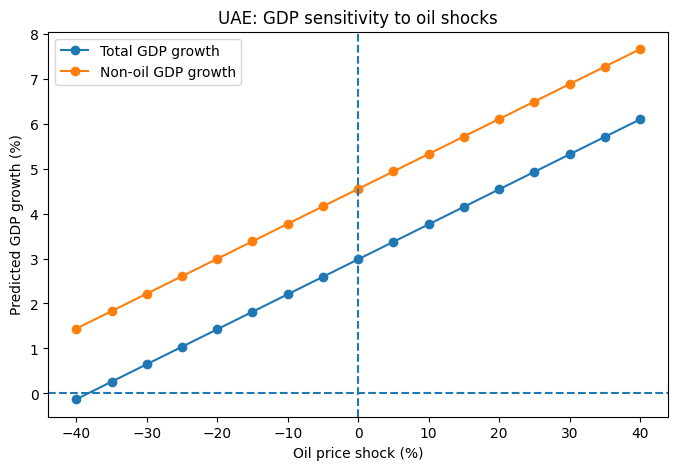

In [8]:
# =========================
# 5. SENSITIVITY CURVES
# =========================

oil_range = np.arange(-40, 41, 5)

curve = pd.DataFrame({"OilShock": oil_range})

curve["Pred_Total"] = (
    model_total.params["const"]
    + model_total.params["Oil Price Change"] * curve["OilShock"]
    + model_total.params["Lag Total GDP Growth"] * avg_lag_total
)

curve["Pred_NonOil"] = (
    model_nonoil.params["const"]
    + model_nonoil.params["Oil Price Change"] * curve["OilShock"]
    + model_nonoil.params["Lag Non-Oil GDP Growth"] * avg_lag_nonoil
)

plt.figure(figsize=(8,5))
plt.plot(curve["OilShock"], curve["Pred_Total"], marker="o", label="Total GDP growth")
plt.plot(curve["OilShock"], curve["Pred_NonOil"], marker="o", label="Non-oil GDP growth")
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Oil price shock (%)")
plt.ylabel("Predicted GDP growth (%)")
plt.title("UAE: GDP sensitivity to oil shocks")
plt.legend()
plt.show()

In [9]:
# =========================
# 6. OPTIONAL EXTENDED NON-OIL MODEL WITH FDI
# =========================

Y_ext = df["Non-Oil Real GDP Growth (%)"]
X_ext = df[["Oil Price Change", "FDI net inflows (% of GDP)", "Lag Non-Oil GDP Growth"]]
X_ext = sm.add_constant(X_ext)

model_ext = sm.OLS(Y_ext, X_ext).fit()
print(model_ext.summary())

                                 OLS Regression Results                                
Dep. Variable:     Non-Oil Real GDP Growth (%)   R-squared:                       0.212
Model:                                     OLS   Adj. R-squared:                  0.094
Method:                          Least Squares   F-statistic:                     1.794
Date:                         Sat, 18 Apr 2026   Prob (F-statistic):              0.181
Time:                                 11:45:27   Log-Likelihood:                -68.182
No. Observations:                           24   AIC:                             144.4
Df Residuals:                               20   BIC:                             149.1
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

In [10]:
# =========================
# 7. OPTIONAL EXTENDED NON-OIL MODEL WITH NON-OIL REVENUE RATIO
# =========================

df_rev = pd.read_excel(file_name, sheet_name=sheet_name)

df_rev = df_rev[[
    "Year",
    "Non-Oil Real GDP Growth (%)",
    "Oil Price Change",
    "Lag Non-Oil GDP Growth",
    "Non-oil Revenue for General Government (% of Non-oil GDP)"
]].dropna().copy()

Y_rev = df_rev["Non-Oil Real GDP Growth (%)"]
X_rev = df_rev[[
    "Oil Price Change",
    "Lag Non-Oil GDP Growth",
    "Non-oil Revenue for General Government (% of Non-oil GDP)"
]]
X_rev = sm.add_constant(X_rev)

model_rev = sm.OLS(Y_rev, X_rev).fit()
print(model_rev.summary())

                                 OLS Regression Results                                
Dep. Variable:     Non-Oil Real GDP Growth (%)   R-squared:                       0.302
Model:                                     OLS   Adj. R-squared:                  0.197
Method:                          Least Squares   F-statistic:                     2.881
Date:                         Sat, 18 Apr 2026   Prob (F-statistic):             0.0615
Time:                                 11:45:45   Log-Likelihood:                -66.733
No. Observations:                           24   AIC:                             141.5
Df Residuals:                               20   BIC:                             146.2
Df Model:                                    3                                         
Covariance Type:                     nonrobust                                         
                                                                coef    std err          t      P>|t|      [0.025      0